In [ ]:
from eigenevo_test import multi_evo
from eigenplotter_test import plot_multirun

#---DATA gen params---
d = 10000
greedy = False
flip_mp_pl = False
flip_mp_hyb = True
n_passes = 10
seed = 38
#---------------------


#---EVO params---
eta = 0.2
b_step = 0.25
b_min = 0
b_max = 1
t_in = 1e-5
t_fin = 1e8
nsteps = 1
init_norm = False        #If True, renormalize each curve with its value at t = 0 
logspacing = True
#----------------


alphas = [0.5, 1.0, 1.5]
n_runs = 50

for a in alphas:
    multi_evo(d, n_runs, a, eta, flip_mp_hyb, b_step, b_min, b_max, t_in, t_fin, nsteps, init_norm, logspacing)




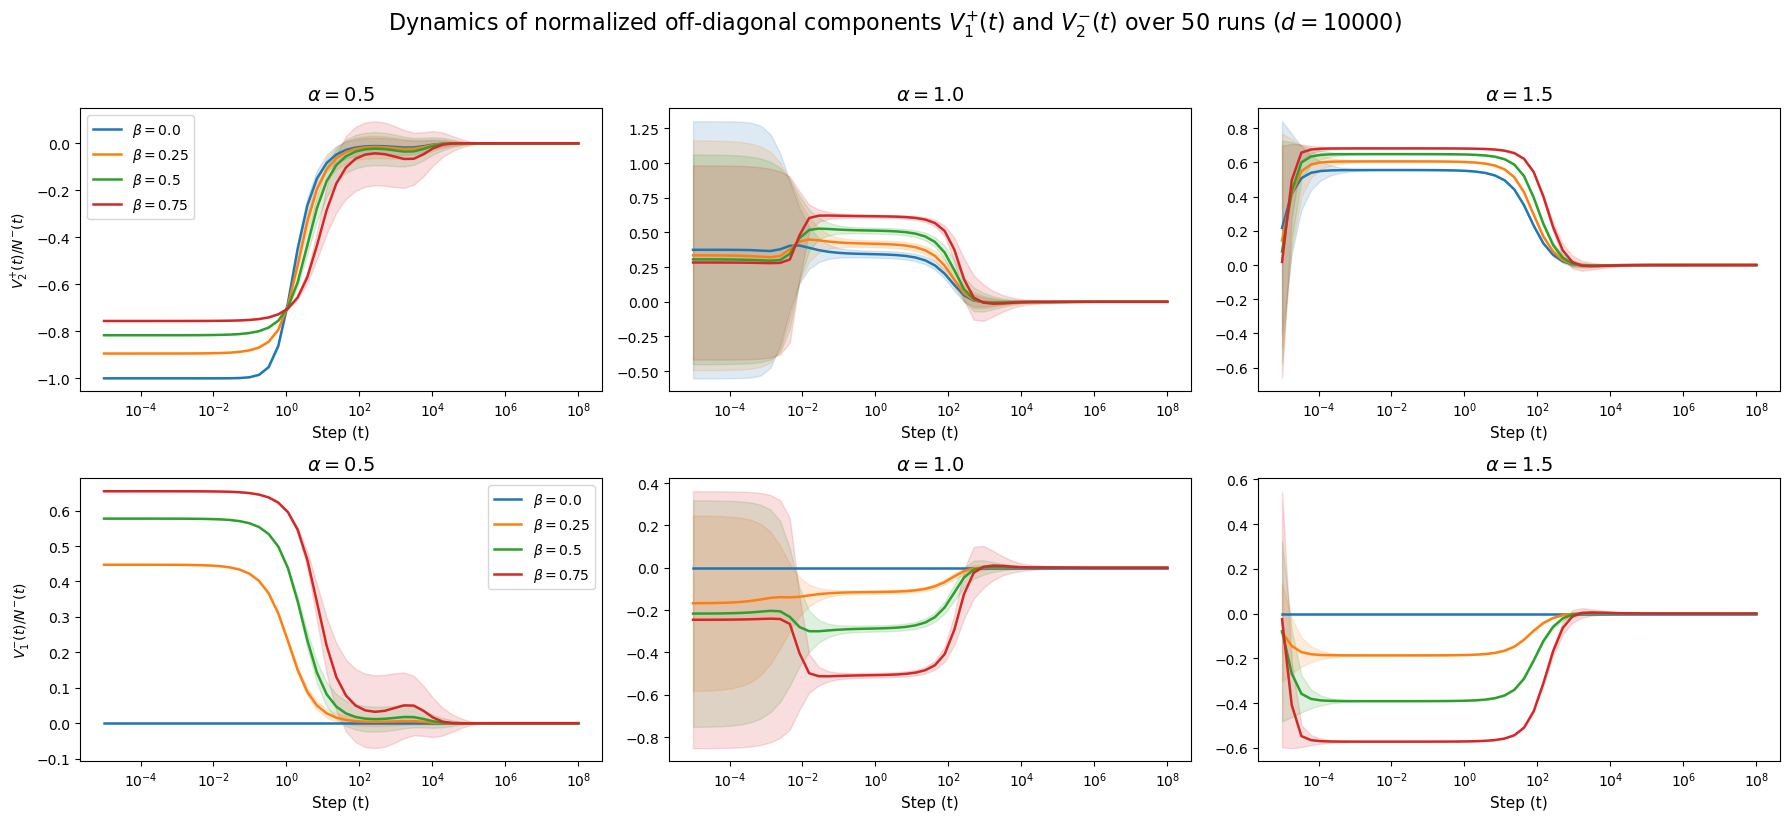

In [2]:
plot_multirun(alphas, n_runs, d, flip_mp_hyb, init_norm)

In [25]:
from eigenevo_test import multi_evo
from eigenevo_test import tokens_struc, components, evolution
from eigenplotter_test import plot_alphas_offdiag, plot_alphas_diag


#---DATA gen params---
d = 10000
greedy = False
flip_mp_pl = False
flip_mp_hyb = True
n_passes = 10
seed = 1
#---------------------


#---EVO params---
eta = 0.2
b_step = 0.25
b_min = 0
b_max = 1
t_in = 1e-5
t_fin = 1e8
nsteps = 1
init_norm = False        #If True, renormalize each curve with its value at t = 0 
logspacing = True
#----------------


alphas = [0.5, 1.0, 1.5]


for a in alphas:
    pi , ui = tokens_struc(d, a, greedy, flip_mp_pl, flip_mp_hyb, n_passes, seed)
    print(ui[0])
    evolution(a, d, pi, ui, eta, b_step, b_min, b_max, t_in, t_fin, nsteps, init_norm, logspacing)

1
1
1


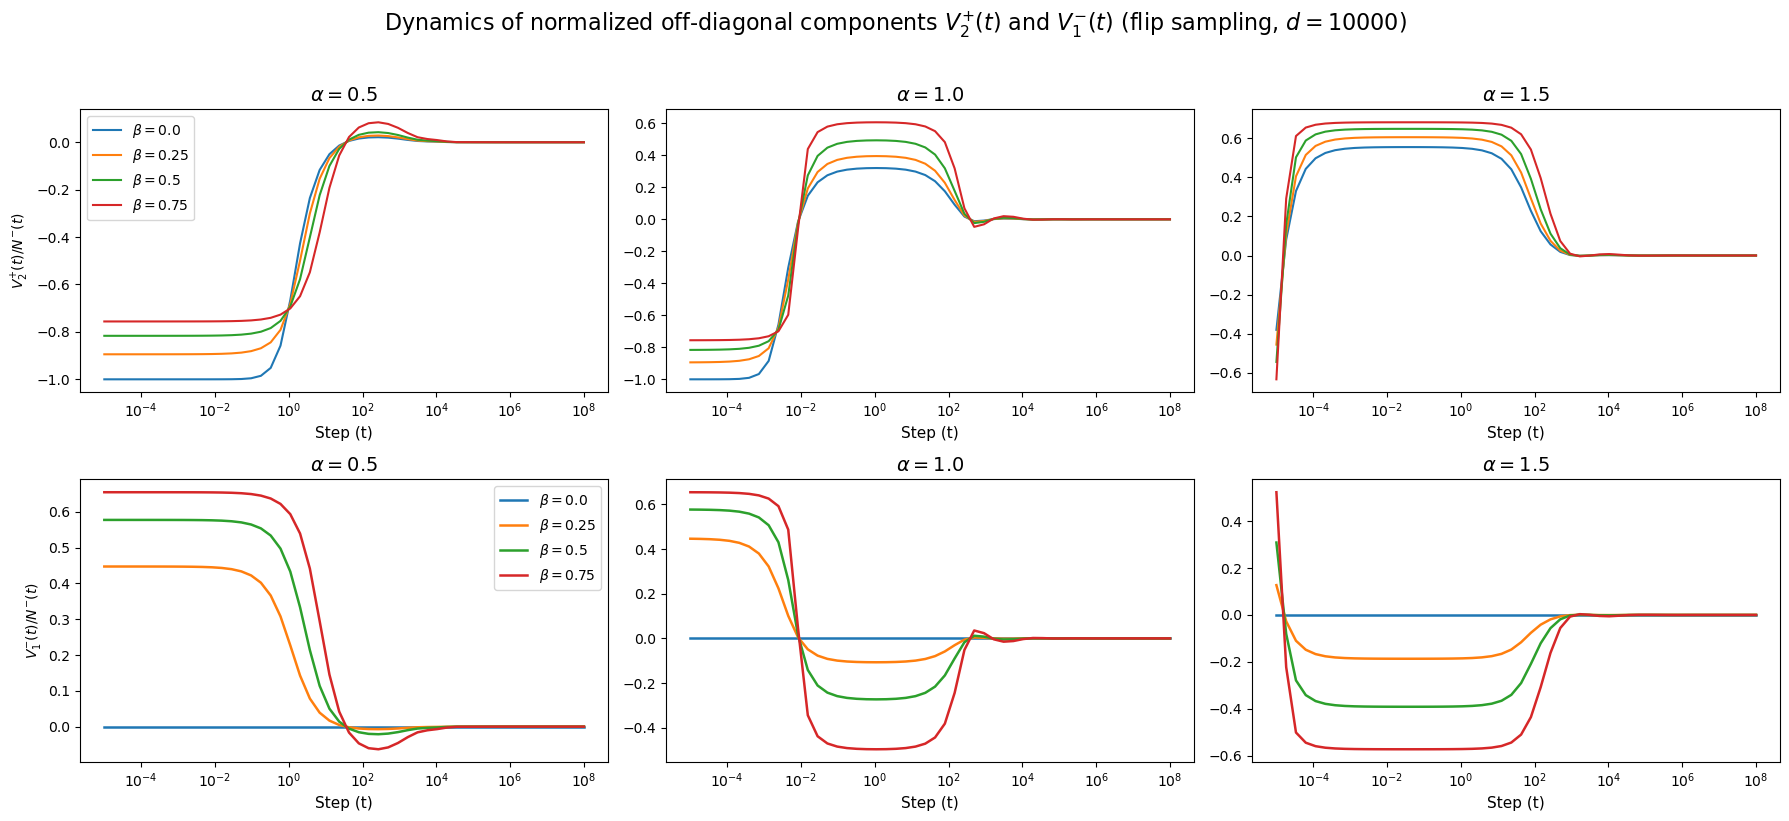

In [22]:
plot_alphas_offdiag(alphas, d, greedy)

-1
-1
-1


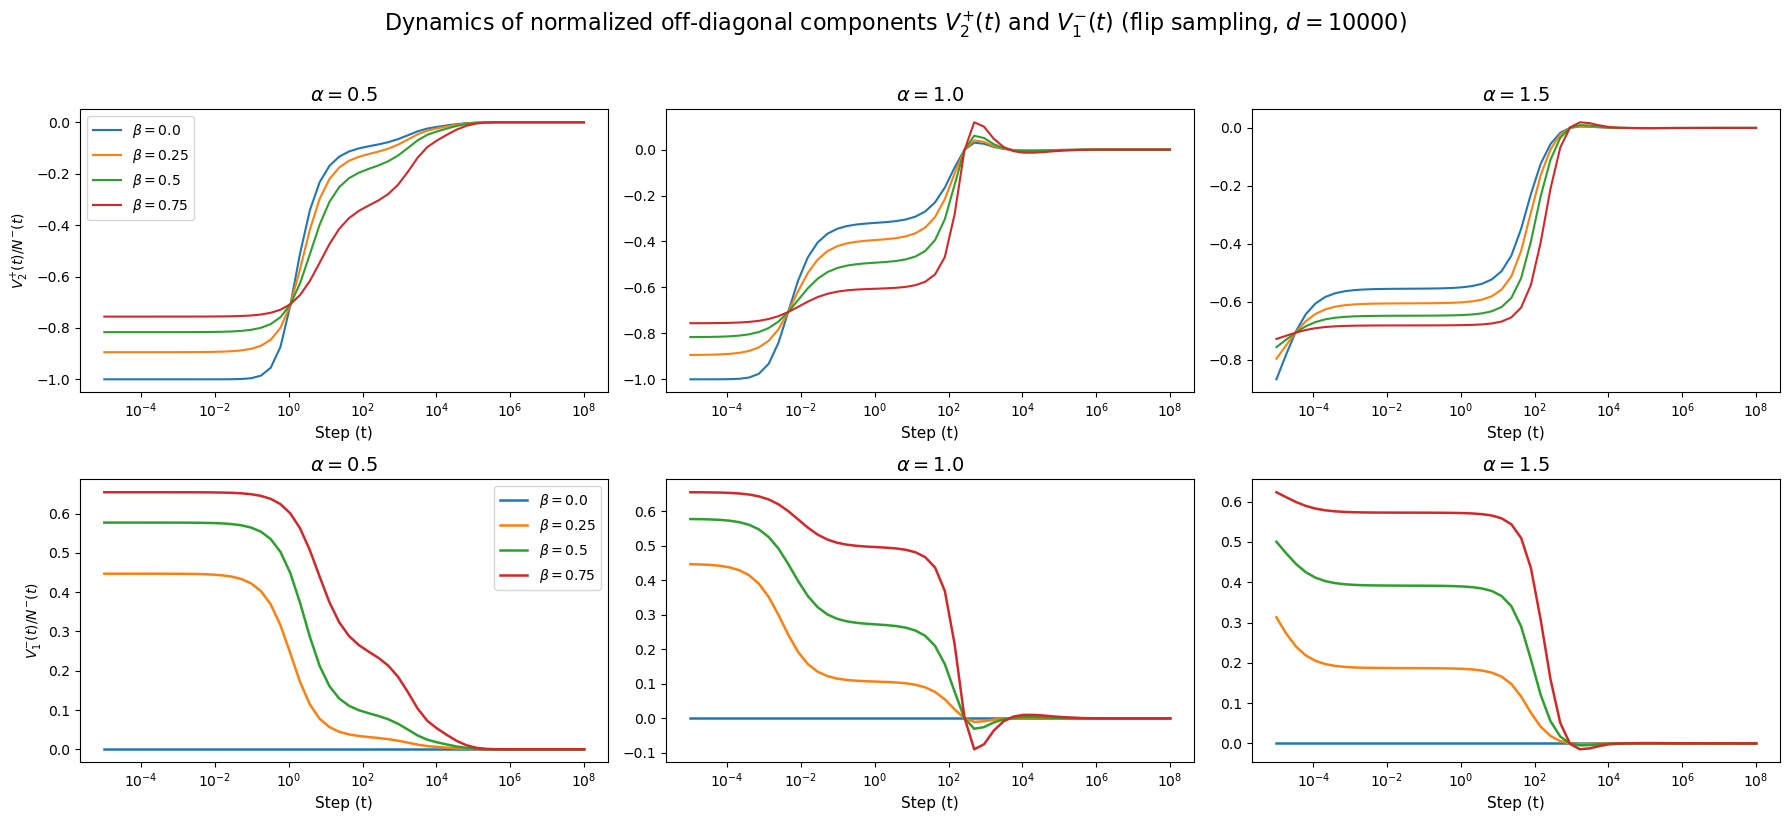

In [24]:
seed = 2
for a in alphas:
    pi , ui = tokens_struc(d, a, greedy, flip_mp_pl, flip_mp_hyb, n_passes, seed)
    print(ui[0])
    evolution(a, d, pi, ui, eta, b_step, b_min, b_max, t_in, t_fin, nsteps, init_norm, logspacing)
plot_alphas_offdiag(alphas, d, greedy)

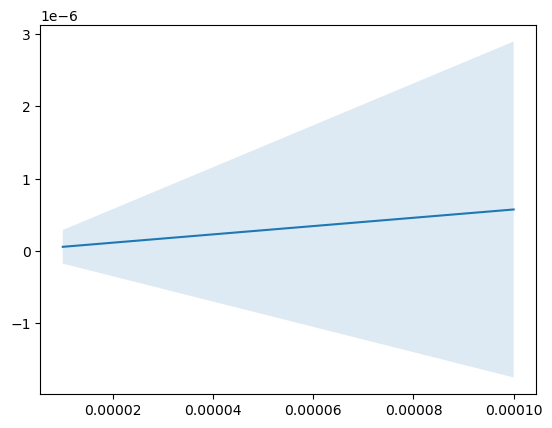

In [18]:
from eigenevo_test import tokens_struc
import numpy as np
import matplotlib.pyplot as plt


d = 10000
a = 1.5
greedy = False
flip_mp_pl = False
flip_mp_hyb = True
t_in = 1e-5
t_fin = 1e-4
n_runs = 50
eta = 0.2

#---nu_t for t<<1---

ss = np.random.SeedSequence(entropy=None)
seeds = ss.generate_state(n_runs)
t_ax = np.geomspace(t_in, t_fin) # Assuming num is specified

nu_t_runs = []

for i, seed in enumerate(seeds):
    pi, ui = tokens_struc(d, a, greedy, flip_mp_pl, flip_mp_hyb, n_passes, seed)
    
    nu_t = - eta * t_ax * ((pi ** 2) @ ui)
    
    nu_t_runs.append(nu_t)

nu_t_runs = np.array(nu_t_runs)

nu_t_mean = np.mean(nu_t_runs, axis=0)
nu_t_std = np.std(nu_t_runs, axis=0)

plt.plot(t_ax, nu_t_mean)
plt.fill_between(t_ax, nu_t_mean - nu_t_std, nu_t_mean + nu_t_std, alpha=0.15)
